## Requirements for Final Project

1. Choose one of the provided data sets (Twitter || Delivery).               
    -> Choosen Twitter Dataset         
2. Identify an interesting research question / analytical challenge    

“How do the dominant topics and sentiments of Twitter conversations vary across spatial clusters in New York City across different seasons, and what do these variations reveal about the city’s changing social and urban dynamics?”
          
3. Conduct the appropriate analysis                    
    -> What are the top 10 topics talked in each season in an year.                  
    -> Make comparison visualisations a seasons in the year.              
    -> Make comparision for on season in all the year 2021.             
    -> What Interesting trends were observed from this?


##### *Four seasons in New York City: Winter (December–February), Spring (March–May), Summer (June–August), and Autumn (September–November)*

                    

# Year - 2021 Analysis

**Dataset:** NYC data - 2020 December to 2021 November

In [1]:
import sqlite3
import pandas as pd
import glob
import os
import warnings
import logging
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

# --- Text Processing ---
import spacy, string
from spacy.lang.en.stop_words import STOP_WORDS
import re
from tqdm import tqdm
tqdm.pandas()

# --- Clustering ---
from sklearn.cluster import KMeans

# --- LDA ---
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


In [ ]:
# Retriving the data from the database 

# --- Path to your folder containing all the .db files ---
DB_DIR = "NYC_2021"

# --- Converting a datetime to a season string ---

def get_season_from_date(date):
    if pd.isna(date):
        return "Unknown"
    month = date.month
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    else:
        return "Unknown"

dfs = []

# --- creating DB connection ---
for db_file in glob.glob(os.path.join(DB_DIR, "*.db")):
    print(f"Processing {db_file} ...")
    conn = sqlite3.connect(db_file)
    
    # --- Join tweets + sentiment + LIWC + place ---
    query = """
    SELECT 
        t.item_number,
        t.id AS tweet_id,
        t.created_at,
        t.created_timestamp,
        t.text,
        t.lang,
        t.geo_lat,
        t.geo_lon,
        s.Positive AS sentiment_pos,
        s.Negative AS sentiment_neg,
        s.Compound AS sentiment_compound,
        l.Analytic AS liwc_analytic,
        l.Clout AS liwc_clout,
        l.Authentic AS liwc_authentic,
        l.Tone AS liwc_tone,
        p.full_name AS place_name,
        p.country_code AS country_code
    FROM tweets AS t
    LEFT JOIN sentiment AS s ON t.item_number = s.item_number
    LEFT JOIN LIWC AS l ON t.item_number = l.item_number
    LEFT JOIN place AS p ON t.place_id = p.place_id
    WHERE t.geo_lat IS NOT NULL AND t.geo_lon IS NOT NULL;
    """
    
    try:
        temp_df = pd.read_sql_query(query, conn)
    except Exception as e:
        print(f"⚠️ Skipped {db_file} due to error: {e}")
        conn.close()
        continue

    conn.close()

    # --- Parsing datetime ---
    
    if "created_at" in temp_df.columns:
        temp_df["created_at"] = pd.to_datetime(temp_df["created_at"], errors="coerce")
    elif "created_timestamp" in temp_df.columns:
        temp_df["created_at"] = pd.to_datetime(temp_df["created_timestamp"], errors="coerce")
    else:
        temp_df["created_at"] = pd.NaT

    # --- Deriving season from date ---
    temp_df["season"] = temp_df["created_at"].apply(get_season_from_date)

    # --- Adding metadata ---
    temp_df["source_db"] = os.path.basename(db_file)

    dfs.append(temp_df)

# --- Combining all seasonal data ---
df = pd.concat(dfs, ignore_index=True)
df.drop_duplicates(subset=["text"], inplace=True)

print(f"✅ Combined {len(df):,} tweets from {len(dfs)} databases.")
print(df["season"].value_counts())
df.head()


Processing NYC_2021\month_2020_12.db ...


In [4]:
# Checking the dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 873939 entries, 0 to 952571
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   item_number         873939 non-null  int64              
 1   tweet_id            873939 non-null  int64              
 2   created_at          873939 non-null  datetime64[ns, UTC]
 3   created_timestamp   873939 non-null  object             
 4   text                873939 non-null  object             
 5   lang                873939 non-null  object             
 6   geo_lat             873939 non-null  object             
 7   geo_lon             873939 non-null  object             
 8   sentiment_pos       873939 non-null  float64            
 9   sentiment_neg       873939 non-null  float64            
 10  sentiment_compound  873939 non-null  float64            
 11  liwc_analytic       821634 non-null  float64            
 12  liwc_clout          8

In [5]:
# converting geo-coordinates to float
df['geo_lat'] = df['geo_lat'].astype(float)
df['geo_lon'] = df['geo_lon'].astype(float)
df['geo_lat'].dtype, df['geo_lon'].dtype


(dtype('float64'), dtype('float64'))

In [6]:
# Checking the numbers of languages present
df['lang'].unique()

# there are 48 languages present in the dataset

array(['en', 'fr', 'pt', 'es', 'ca', 'ja', 'eu', 'pl', 'und', 'da', 'it',
       'tl', 'de', 'hu', 'fi', 'in', 'ht', 'ro', 'cy', 'tr', 'zh', 'nl',
       'sl', 'ko', 'vi', 'sv', 'et', 'cs', 'no', 'el', 'hi', 'ru', 'lv',
       'lt', 'ar', 'th', 'bn', 'iw', 'ta', 'fa', 'uk', 'bg', 'is', 'ne',
       'pa', 'my', 'ur', 'mr'], dtype=object)

In [7]:
# Filtering english tweets only 
text_en = df[df['lang']=='en']
text_en.shape

(821634, 19)

In [8]:
# Removing outliers from the dataset based on geo-coordinates
tweets_2021 = text_en[
    (text_en['geo_lon'] >= 40.4774) & (text_en['geo_lon'] <= 40.9176) &
    (text_en['geo_lat'] >= -74.2591) & (text_en['geo_lat'] <= -73.7004)
]
tweets_2021.shape

(821632, 19)

### Clustering 4 corners of newyork


C:\Users\Krishnapriya\AppData\Local\Temp\ipykernel_14120\746161076.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_2021["cluster"] = kmeans.fit_predict(coords)
C:\Users\Krishnapriya\AppData\Local\Temp\ipykernel_14120\746161076.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets_2021["cluster_name"] = tweets_2021["cluster"].map(cluster_names)


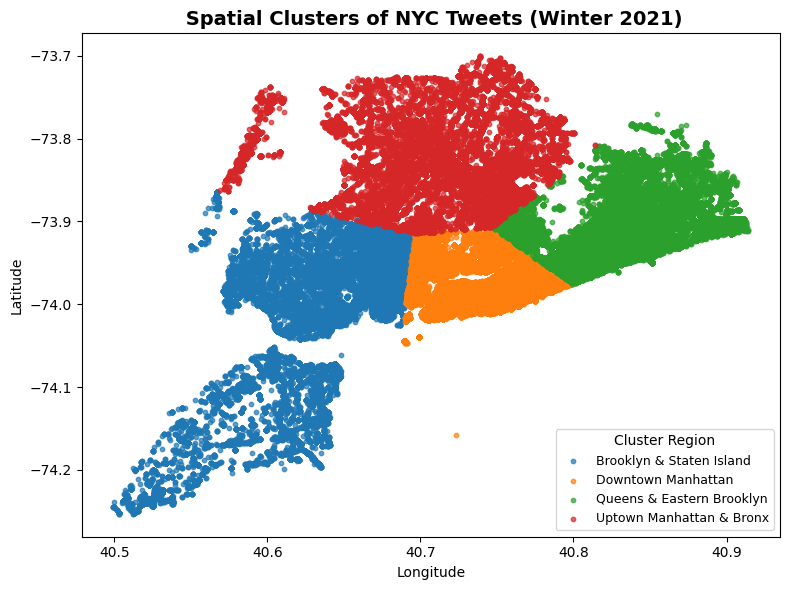

In [12]:
# Spatial clustering 

# --- Select geospatial data ---
coords = tweets_2021[["geo_lon", "geo_lat"]]

# --- Defining number of clusters ---
N_CLUSTERS = 4

# --- KMeans clustering ---
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
tweets_2021["cluster"] = kmeans.fit_predict(coords)

# --- Define custom names for each cluster ---
cluster_names = {
    0: "Downtown Manhattan",
    1: "Brooklyn & Staten Island",
    2: "Uptown Manhattan & Bronx",
    3: "Queens & Eastern Brooklyn"
}

# --- Mapping numeric cluster IDs to descriptive names ---
tweets_2021["cluster_name"] = tweets_2021["cluster"].map(cluster_names)

# --- Visualizing the clusters with names ---
plt.figure(figsize=(8, 6))

# --- Creating scatter plot with color coding by cluster ---
for name, group in tweets_2021.groupby("cluster_name"):
    plt.scatter(group["geo_lon"], group["geo_lat"], s=10, label=name, alpha=0.7)

plt.title(" Spatial Clusters of NYC Tweets (Winter 2021)", fontsize=14, weight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster Region", fontsize=9)
plt.tight_layout()
plt.show()


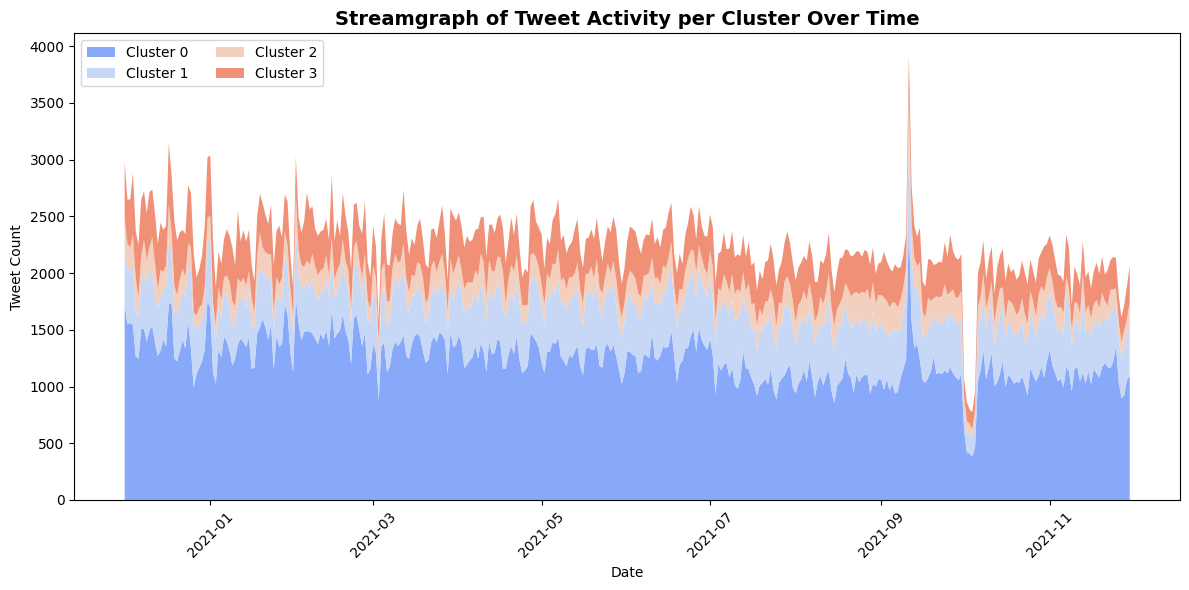

In [14]:
# streamgraph to check Tweet Activity per Cluster Over Time
# Convert 'created_at' to datetime and extract date part
tweets_2021['date'] = pd.to_datetime(tweets_2021['created_at']).dt.date

# Group by date and cluster
grouped = tweets_2021.groupby(['date', 'cluster']).size().unstack(fill_value=0)

# Sort by date to ensure proper timeline
grouped = grouped.sort_index()

# Streamgraph-like stacked area
plt.figure(figsize=(12, 6))
plt.stackplot(grouped.index, grouped.T, labels=[f'Cluster {i}' for i in grouped.columns],
              colors=sns.color_palette("coolwarm", len(grouped.columns)), alpha=0.9)
plt.title("Streamgraph of Tweet Activity per Cluster Over Time", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.legend(loc='upper left', ncol=2)

# Format x-axis for better date display
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
tweets_2021.to_csv("Outputs_2021/Clustered_dataset_2021.csv", index = False)

In [2]:
tweets_2021 = pd.read_csv("Outputs_2021/Clustered_dataset_2021.csv")

In [5]:

# Basic Text preprocessing using Spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_text(text):
    text = re.sub(r"http\S+", "", str(text))        # URLs
    text = re.sub(r"@\w+", "", text)                # mentions
    text = re.sub(r"#", "", text)                   # remove #
    text = re.sub(r"[^A-Za-z\s]", "", text)         # special chars
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc 
        if token.lemma_ not in STOP_WORDS and token.is_alpha and len(token) > 2
    ]
    return " ".join(tokens)

In [3]:
# filtering only for different seasons
winter_tweets_2021 = tweets_2021[tweets_2021['season'] == "Winter"]
summer_tweets_2021 = tweets_2021[tweets_2021['season'] == "Summer"]
spring_tweets_2021 = tweets_2021[tweets_2021['season'] == "Spring"]
fall_tweets_2021 = tweets_2021[tweets_2021['season'] == "Fall"]
print(winter_tweets_2021.shape, summer_tweets_2021.shape, spring_tweets_2021.shape, fall_tweets_2021.shape)

(219358, 21) (202923, 21) (213751, 21) (185600, 21)


In [10]:
# Removing duplicates
winter_tweets_2021 = winter_tweets_2021.drop_duplicates(subset=['text'])
spring_tweets_2021 = spring_tweets_2021.drop_duplicates(subset=['text'])
summer_tweets_2021 = summer_tweets_2021.drop_duplicates(subset=['text'])
fall_tweets_2021 = fall_tweets_2021.drop_duplicates(subset=['text'])

In [11]:
# saving the seasonal datasets
winter_tweets_2021.to_csv('Datasets_2021/Winter_tweets_2021.csv', index = False)
spring_tweets_2021.to_csv('Datasets_2021/Spring_tweets_2021.csv', index = False)
summer_tweets_2021.to_csv('Datasets_2021/Summer_tweets_2021.csv', index = False)
fall_tweets_2021.to_csv('Datasets_2021/Fall_tweets_2021.csv', index = False)

In [3]:
# Text processing for retriving parts of speech using Spacy
nlp = spacy.load("en_core_web_sm")

def spacy_clean(text):
    doc = nlp(text)
    tokens = [
        token.lemma_.lower() for token in doc
        if token.pos_ in ["NOUN", "ADJ", "VERB"]
        and not token.is_stop
        and token.is_alpha
    ]
    return " ".join(tokens)



In [5]:
# Adding parts of speech for winter tweets
winter_tweets_2021["spacy_clean"] = winter_tweets_2021["clean_text"].astype(str).progress_apply(spacy_clean)
winter_tweets_2021.head()


100%|██████████| 219286/219286 [20:43<00:00, 176.32it/s]


,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_analytic,liwc_clout,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,clean_text,spacy_clean
0,2,1333923797108477954,2020-12-01 23:59:50+00:00,1606867190,Updated: Incident on #BeltSystemLaureltonParkw...,en,-73.729698,40.678699,0.000,0.0,...,99.00,40.06,2.93,1.00,"Queens, NY",US,Winter,month_2020_12.db,update incident beltsystemlaureltonparkway avenue,beltsystemlaureltonparkway avenue
1,14,1333923698445783041,2020-12-01 23:59:27+00:00,1606867167,The Difference Between Indicators &amp; SKILL....,en,-74.006400,40.714200,0.000,0.0,...,98.55,11.66,89.39,96.74,"Manhattan, NY",US,Winter,month_2020_12.db,difference indicator amp skill brooklynmose ne...,
2,24,1333923642720231424,2020-12-01 23:59:14+00:00,1606867154,8th Avenue #8thavenue #midtownmanhattannyc #mi...,en,-73.992894,40.750514,0.000,0.0,...,94.68,40.06,24.32,1.00,"Manhattan, NY",US,Winter,month_2020_12.db,avenue thavenue midtownmanhattannyc midtownman...,unedited canond canonphotography canonphotogra...
3,34,1333923589645623297,2020-12-01 23:59:01+00:00,1606867141,Cleared: Incident on #StatenIslandRailway NB f...,en,-74.251961,40.512764,0.135,0.0,...,99.00,40.06,1.00,20.23,"Staten Island, NY",US,Winter,month_2020_12.db,clear incident statenislandrailway tottenville...,
4,35,1333923559253544960,2020-12-01 23:58:54+00:00,1606867134,JUPOPPIN @gilliangarciaartistry\n\nhttps://t.c...,en,-73.950220,40.635490,0.000,0.0,...,89.52,40.06,1.00,1.00,"Brooklyn, NY",US,Winter,month_2020_12.db,jupoppin gillian garcia artistry,


In [6]:
# Adding parts of speech for spring tweets
spring_tweets_2021["spacy_clean"] = spring_tweets_2021["clean_text"].astype(str).progress_apply(spacy_clean)
spring_tweets_2021.head()


100%|██████████| 213661/213661 [24:14<00:00, 146.88it/s]


,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_analytic,liwc_clout,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,clean_text,spacy_clean
0,7,1366538700629409794,2021-03-01 23:59:49+00:00,1614643189,Incident on #Q27Bus Both directions at Holly A...,en,-73.815593,40.752978,0.000,0.000,...,98.78,40.06,1.91,1.00,"Queens, NY",US,Spring,month_2021_03.db,incident qbus direction holly avburle,direction
1,28,1366538474988441603,2021-03-01 23:58:56+00:00,1614643136,Construction on #DLine NB from 36 St to DeKalb...,en,-74.003549,40.655144,0.000,0.000,...,99.00,40.06,1.00,1.00,"Brooklyn, NY",US,Spring,month_2021_03.db,construction dline dekalb,construction dline dekalb
2,29,1366538473528786946,2021-03-01 23:58:55+00:00,1614643135,Construction on #NLine from Coney Island - Sti...,en,-73.981233,40.577422,0.000,0.000,...,99.00,40.06,1.00,1.00,"Brooklyn, NY",US,Spring,month_2021_03.db,construction nline coney island stillwell asto...,construction
3,30,1366538473222664192,2021-03-01 23:58:55+00:00,1614643135,Cleared: Incident on #SIM35Bus at lower level...,en,-74.069100,40.603479,0.111,0.175,...,99.00,40.06,50.45,20.23,"Staten Island, NY",US,Spring,month_2021_03.db,clear incident simbus low level verrazzanonarr...,low level verrazzanonarrow bridge
4,31,1366538472736055296,2021-03-01 23:58:55+00:00,1614643135,Construction on #DLine NB from 36 St to DeKalb...,en,-74.003549,40.655144,0.000,0.000,...,99.00,40.06,1.00,1.00,"Brooklyn, NY",US,Spring,month_2021_03.db,construction dline dekalb,construction dline dekalb


In [10]:
# Adding parts of speech for summer tweets
summer_tweets_2021["spacy_clean"] = summer_tweets_2021["clean_text"].astype(str).progress_apply(spacy_clean)
summer_tweets_2021.head()


100%|██████████| 202865/202865 [32:11<00:00, 105.02it/s]


,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_analytic,liwc_clout,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,clean_text,spacy_clean
0,10,1399878342468325383,2021-06-01 23:59:39+00:00,1622591979,Somebody stole somebody's money here no respec...,en,-73.841454,40.721773,0.000,0.213,...,36.67,70.59,8.42,20.23,"Queens, NY",US,Summer,month_2021_06.db,somebody steal somebodys money respect forest ...,steal somebodys money respect forest view cent...
1,45,1399877963290718212,2021-06-01 23:58:09+00:00,1622591889,"Beauty in the Spiritual Life, Part 2: Suggesti...",en,-74.000761,40.720756,0.352,0.000,...,99.00,16.63,24.32,1.00,"Manhattan, NY",US,Summer,month_2021_06.db,beauty spiritual life suggestion develop impul...,beauty spiritual life suggestion develop impul...
2,46,1399877960274960388,2021-06-01 23:58:08+00:00,1622591888,The Daily Hustle! 💰😎@femhundrahall @ Fem Hundr...,en,-73.889744,40.854763,0.230,0.000,...,97.04,40.06,3.81,1.00,"Bronx, NY",US,Summer,month_2021_06.db,daily hustle fem hundra hall,daily
3,56,1399877880818118663,2021-06-01 23:57:49+00:00,1622591869,Hope to have you all join the Club @ Manhattan...,en,-73.967500,40.777900,0.362,0.000,...,89.52,94.84,1.00,99.00,"Manhattan, NY",US,Summer,month_2021_06.db,hope join club manhattan new york,
4,68,1399877758394802176,2021-06-01 23:57:20+00:00,1622591840,19” SPA wheels mounted! #volvo #volvoS80 #volv...,en,-74.088900,40.630300,0.000,0.000,...,89.52,40.06,4.38,20.23,"Staten Island, NY",US,Summer,month_2021_06.db,spa wheel mount volvo volvos volvosv volvosvex...,volvosvexecutive volvomoment volvoforlife vcoa...


In [8]:
# Adding parts of speech for Fall tweets
fall_tweets_2021["spacy_clean"] = fall_tweets_2021["clean_text"].astype(str).progress_apply(spacy_clean)
fall_tweets_2021.head()


100%|██████████| 185559/185559 [15:19<00:00, 201.89it/s]


,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_analytic,liwc_clout,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,clean_text,spacy_clean
0,20,1433217928422428679,2021-09-01 23:59:16+00:00,1630540756,#thewritingcircle #thelair @thelair2021 @nicho...,en,-73.918069,40.695277,0.0,0.0,...,89.52,40.06,1.00,1.00,"Brooklyn, NY",US,Fall,month_2021_09.db,thewritingcircle thelair bushwick,
1,45,1433217746901274624,2021-09-01 23:58:33+00:00,1630540713,Just posted a photo @ Ridgewood European Pork ...,en,-73.911466,40.705003,0.0,0.0,...,89.52,40.06,1.00,1.00,"Queens, NY",US,Fall,month_2021_09.db,post photo ridgewood european pork store,photo ridgewood pork store
2,60,1433217574242824195,2021-09-01 23:57:52+00:00,1630540672,#wednesday #⛈ @ Union Square https://t.co/uD0c...,en,-73.991916,40.736910,0.0,0.0,...,89.52,40.06,89.39,1.00,"Manhattan, NY",US,Fall,month_2021_09.db,wednesday union square,
3,92,1433217296227610626,2021-09-01 23:56:45+00:00,1630540605,"Just posted a photo @ Manhattan, New York http...",en,-73.967500,40.777900,0.0,0.0,...,89.52,40.06,3.81,20.23,"Manhattan, NY",US,Fall,month_2021_09.db,post photo manhattan new york,
4,95,1433217255869976581,2021-09-01 23:56:36+00:00,1630540596,Just posted a photo @ Throgs Neck https://t.co...,en,-73.822030,40.820175,0.0,0.0,...,89.52,40.06,1.00,1.00,"Bronx, NY",US,Fall,month_2021_09.db,post photo throg neck,post photo throg neck


### LDA

In [ ]:
# Text of spacy clean


def get_top_words(model, feature_names, n_top_words=10):
    return [" ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
            for topic in model.components_]

results = []
vectorizer = CountVectorizer(max_df=0.9, min_df=10, ngram_range=(1,2))

for cluster_id in sorted(winter_tweets_2021["cluster"].unique()):
    cluster_texts = winter_tweets_2021[winter_tweets_2021["cluster"] == cluster_id]["spacy_clean"]
    X = vectorizer.fit_transform(cluster_texts)

    lda = LatentDirichletAllocation(n_components=5, random_state=42)
    lda.fit(X)

    feature_names = vectorizer.get_feature_names_out()
    top_words = get_top_words(lda, feature_names, n_top_words=5)

    for i, topic in enumerate(top_words):
        results.append({"cluster": cluster_id, "topic": f"Topic_{i+1}", "keywords": topic})

winter_topics_df = pd.DataFrame(results)



,cluster,topic,keywords
0,0,Topic_1,traffic stop stop traffic accident block
1,0,Topic_2,photo post bronx post photo video
2,0,Topic_3,incident line direction clear exit
3,0,Topic_4,spade king king spade spade king ace
4,0,Topic_5,city bronx avenue harlem photo
5,1,Topic_1,new year time happy love
6,1,Topic_2,post photo post photo video post video
7,1,Topic_3,good day station city center
8,1,Topic_4,spade king king spade spade king ace
9,1,Topic_5,incident line clear construction central


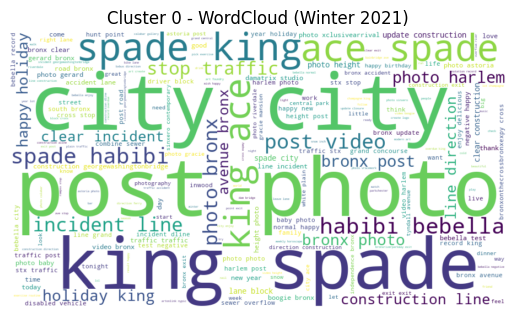

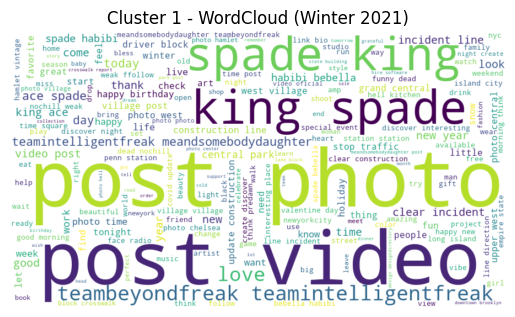

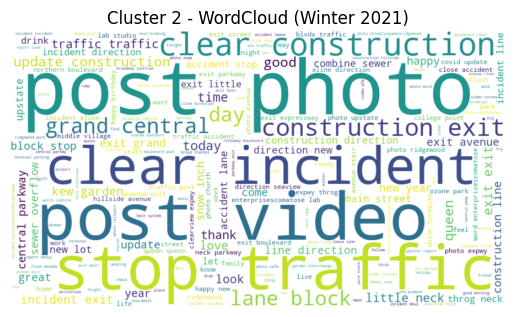

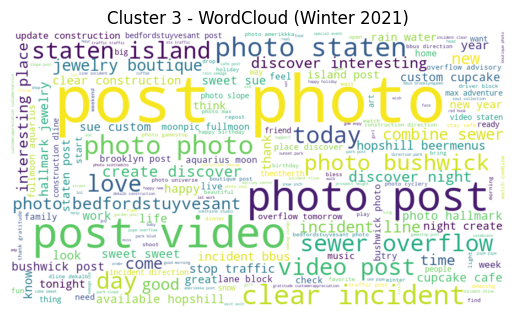

In [45]:
from wordcloud import WordCloud


for cluster in sorted(winter_tweets_2021["cluster"].unique()):
    text = " ".join(winter_tweets_2021[winter_tweets_2021["cluster"] == cluster]["spacy_clean"])
    wc = WordCloud(width=900, height=500, background_color="white").generate(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster} - WordCloud (Winter 2021)")
    plt.show()


C:\Users\Krishnapriya\AppData\Local\Temp\ipykernel_15544\629495151.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=winter_tweets_2021, x="cluster", y="sentiment_compound", palette="coolwarm")


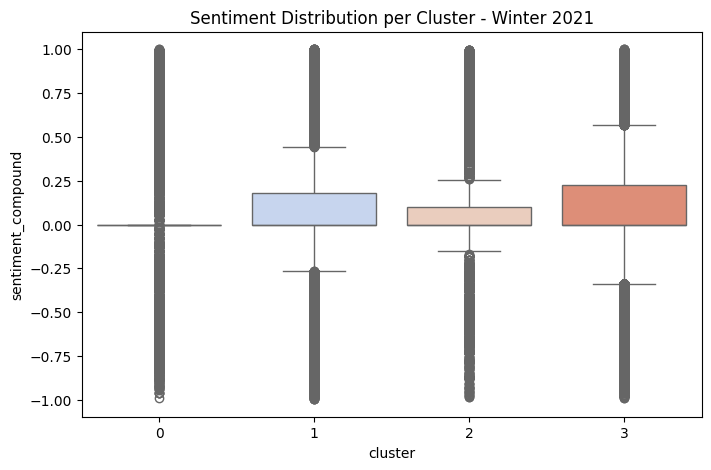

In [46]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(data=winter_tweets_2021, x="cluster", y="sentiment_compound", palette="coolwarm")
plt.title("Sentiment Distribution per Cluster - Winter 2021")
plt.show()


### Improved LDA results 

### Winter tweets 2021

In [12]:

warnings.filterwarnings("ignore")
logging.getLogger("gensim").setLevel(logging.ERROR)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])  # speed up

# --- custom cleaning using Spacy ---
CUSTOM_STOPWORDS = set([
    "photo", "post", "video", "nyc", "amp", "http", "https", "pic", "twitter",
    "today", "night", "day", "love", "people", "street", "city"
])

def clean_text_fast(text):
    text = re.sub(r"http\S+", "", str(text))        # URLs
    text = re.sub(r"@\w+", "", text)                # mentions
    text = re.sub(r"#", "", text)                   # remove #
    text = re.sub(r"[^A-Za-z\s]", "", text) 
    text = re.sub(r"http\S+|www\S+|pic\.twitter\S+", "", str(text))
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and len(token.text) > 3
        and token.text not in CUSTOM_STOPWORDS
        and not token.is_stop
    ]
    return tokens


In [13]:
# Apply cleaning with progress bar
tqdm.pandas(desc="Cleaning tweets")
winter_tweets_2021['tokens'] = winter_tweets_2021['text'].progress_apply(clean_text_fast)

Cleaning tweets: 100%|██████████| 219358/219358 [09:03<00:00, 403.23it/s]


In [15]:

# Defining Fast LDA for Each Cluster (Fixed 5 Topics)
from gensim import corpora, models

def run_fast_lda(cluster_df, cluster_id, num_topics=5):
    texts = cluster_df['tokens'].tolist()
    if len(texts) < 30:
        print(f"Skipping cluster {cluster_id} (too few tweets)")
        return None

    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=30, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # ⚡ Speed-up tip: reduce passes and iterations
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=8,
        iterations=100,
        alpha='auto',
        eta='auto'
    )

    topics = lda_model.show_topics(num_topics=num_topics, num_words=6, formatted=False)
    topic_data = []
    for i, words in topics:
        topic_data.append({
            "cluster": cluster_id,
            "topic_id": f"Topic_{i+1}",
            "keywords": ", ".join([w for w, _ in words])
        })
    return pd.DataFrame(topic_data)




In [16]:

# Running LDA for All 4 Clusters

all_topics = []

for cluster_id in sorted(winter_tweets_2021['cluster'].unique()):
    print(f"\nRunning LDA for Cluster {cluster_id} ...")
    cluster_df = winter_tweets_2021[winter_tweets_2021['cluster'] == cluster_id]
    topic_df = run_fast_lda(cluster_df, cluster_id)
    if topic_df is not None:
        all_topics.append(topic_df)

winter_topics_final = pd.concat(all_topics, ignore_index=True)
winter_topics_final


Running LDA for Cluster 0 ...

Running LDA for Cluster 1 ...

Running LDA for Cluster 2 ...

Running LDA for Cluster 3 ...


,cluster,topic_id,keywords
0,0,Topic_1,"time, square, happy, good, place, link"
1,0,Topic_2,"york, post, station, penn, chelsea, teamintell..."
2,0,Topic_3,"manhattan, king, spade, newyork, william, mccu..."
3,0,Topic_4,"east, village, west, upper, february, manhattan"
4,0,Topic_5,"incident, brooklyn, update, construction, park..."
5,1,Topic_1,"hotel, united, states, discover, jewelry, bout..."
6,1,Topic_2,"construction, incident, avenue, state, exit, d..."
7,1,Topic_3,"incident, bushwick, park, prospect, direction,..."
8,1,Topic_4,"brooklyn, york, post, place, create, discover"
9,1,Topic_5,"island, staten, traffic, snow, stop, sweet"


In [17]:

# Saving the topic to csv 
winter_topics_final.to_csv("Outputs_2021/winter_Cluster_Topics.csv", index=False)

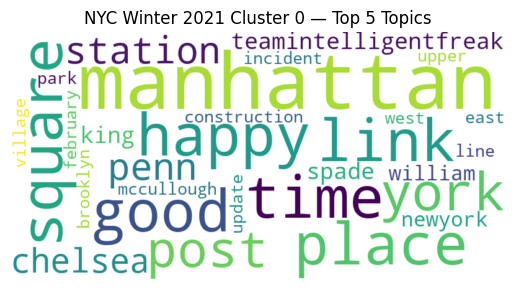

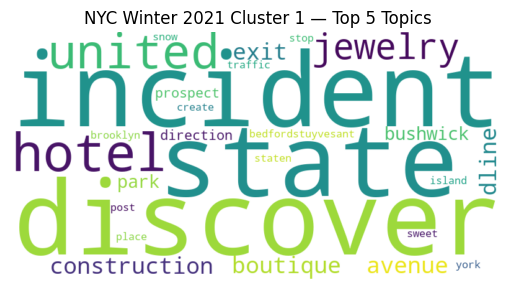

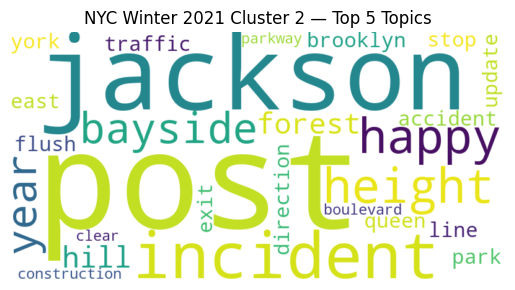

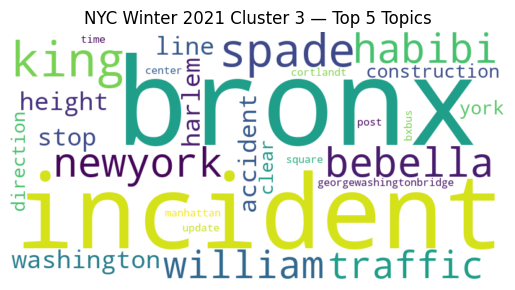

In [19]:
# Wordcloud per cluster
from wordcloud import WordCloud
for cluster_id in winter_topics_final['cluster'].unique():
    subset = winter_topics_final[winter_topics_final['cluster'] == cluster_id]
    text = " ".join(subset['keywords'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"NYC Winter 2021 Cluster {cluster_id} — Top 5 Topics")
    plt.show()


#### Spring tweets 2021 

In [21]:
# Apply cleaning with progress bar
tqdm.pandas(desc="Cleaning tweets")
spring_tweets_2021['tokens'] = spring_tweets_2021['text'].progress_apply(clean_text_fast)

Cleaning tweets: 100%|██████████| 213751/213751 [11:47<00:00, 302.17it/s]


In [22]:
# --- Running for All 4 Clusters

all_topics = []

for cluster_id in sorted(spring_tweets_2021['cluster'].unique()):
    print(f"\nRunning LDA for Cluster {cluster_id} ...")
    cluster_df = spring_tweets_2021[spring_tweets_2021['cluster'] == cluster_id]
    topic_df = run_fast_lda(cluster_df, cluster_id)
    if topic_df is not None:
        all_topics.append(topic_df)

spring_topics_final = pd.concat(all_topics, ignore_index=True)
spring_topics_final


Running LDA for Cluster 0 ...

Running LDA for Cluster 1 ...

Running LDA for Cluster 2 ...

Running LDA for Cluster 3 ...


,cluster,topic_id,keywords
0,0,Topic_1,"good, happy, thank, come, like, time"
1,0,Topic_2,"york, post, manhattan, park, central, knick"
2,0,Topic_3,"east, brooklyn, west, upper, village, long"
3,0,Topic_4,"community, square, board, time, near, manhattan"
4,0,Topic_5,"incident, construction, update, line, directio..."
5,1,Topic_1,"incident, construction, direction, update, cle..."
6,1,Topic_2,"island, staten, happy, bedfordstuyvesant, cone..."
7,1,Topic_3,"brooklyn, york, post, park, prospect, douglass"
8,1,Topic_4,"traffic, block, atlantic, stop, lane, garden"
9,1,Topic_5,"place, bridge, level, low, simbus, construction"


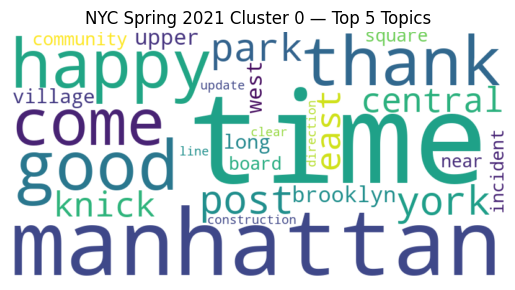

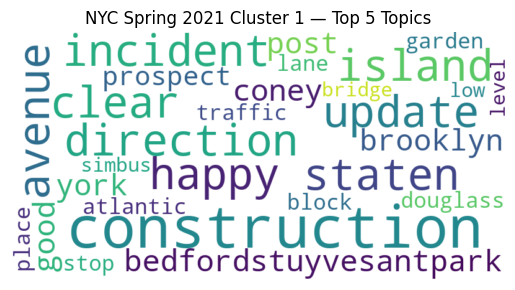

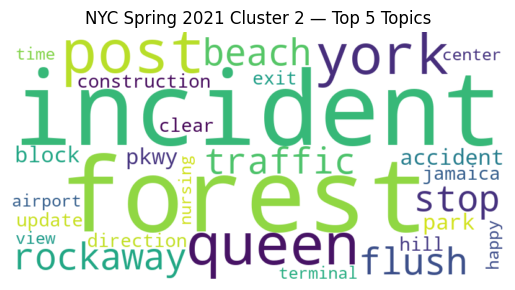

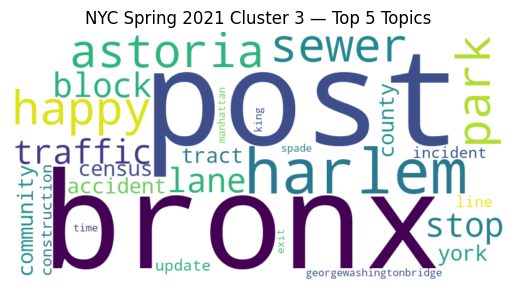

In [23]:
# Wordcloud per cluster
for cluster_id in spring_topics_final['cluster'].unique():
    subset = spring_topics_final[spring_topics_final['cluster'] == cluster_id]
    text = " ".join(subset['keywords'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"NYC Spring 2021 Cluster {cluster_id} — Top 5 Topics")
    plt.show()


### Summer tweets 2021 

In [24]:
# Apply cleaning with progress bar
tqdm.pandas(desc="Cleaning tweets")
summer_tweets_2021['tokens'] = summer_tweets_2021['text'].progress_apply(clean_text_fast)

Cleaning tweets: 100%|██████████| 202923/202923 [11:03<00:00, 305.64it/s]


In [25]:

# --- Run for All 4 Clusters ---

all_topics = []

for cluster_id in sorted(summer_tweets_2021['cluster'].unique()):
    print(f"\nRunning LDA for Cluster {cluster_id} ...")
    cluster_df = summer_tweets_2021[summer_tweets_2021['cluster'] == cluster_id]
    topic_df = run_fast_lda(cluster_df, cluster_id)
    if topic_df is not None:
        all_topics.append(topic_df)

summer_topics_final = pd.concat(all_topics, ignore_index=True)
summer_topics_final


Running LDA for Cluster 0 ...

Running LDA for Cluster 1 ...

Running LDA for Cluster 2 ...

Running LDA for Cluster 3 ...


,cluster,topic_id,keywords
0,0,Topic_1,"incident, construction, update, direction, eas..."
1,0,Topic_2,"like, traffic, look, work, great, newyork"
2,0,Topic_3,"brooklyn, line, community, block, august, board"
3,0,Topic_4,"york, post, manhattan, time, square, good"
4,0,Topic_5,"park, central, madison, radio, grand, apply"
5,1,Topic_1,"incident, construction, community, driver, nea..."
6,1,Topic_2,"park, line, prospect, incident, outside, atlantic"
7,1,Topic_3,"lense, beach, good, happy, color, vision"
8,1,Topic_4,"island, staten, coney, construction, garden, v..."
9,1,Topic_5,"york, post, avenue, bushwick, fourth, jewelry"


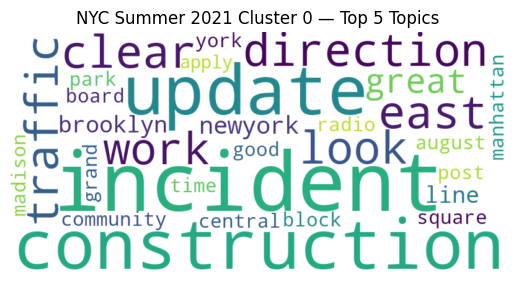

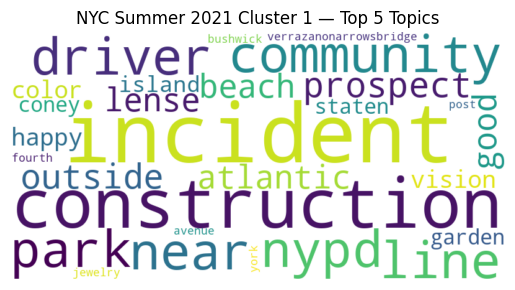

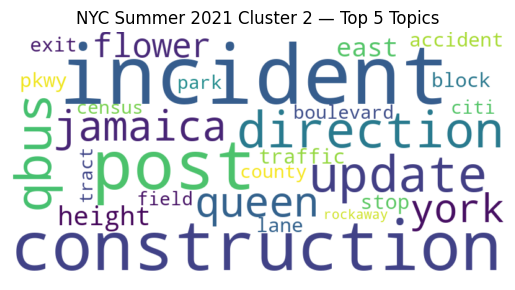

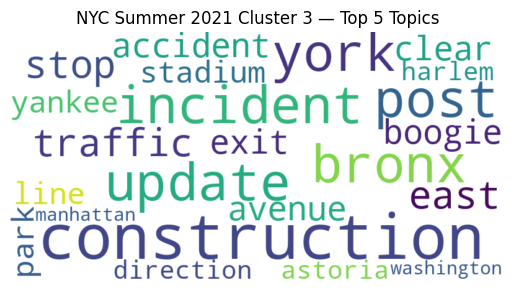

In [26]:
# Wordcloud per cluster
for cluster_id in summer_topics_final['cluster'].unique():
    subset = summer_topics_final[summer_topics_final['cluster'] == cluster_id]
    text = " ".join(subset['keywords'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"NYC Summer 2021 Cluster {cluster_id} — Top 5 Topics")
    plt.show()


###  Fall tweets 2021

In [28]:
# Apply cleaning with progress bar
tqdm.pandas(desc="Cleaning tweets")
fall_tweets_2021['tokens'] = fall_tweets_2021['text'].progress_apply(clean_text_fast)

Cleaning tweets: 100%|██████████| 185600/185600 [08:52<00:00, 348.76it/s]


In [29]:
# =========================================
# STEP 4: Run for All 4 Clusters
# =========================================
all_topics = []

for cluster_id in sorted(fall_tweets_2021['cluster'].unique()):
    print(f"\nRunning LDA for Cluster {cluster_id} ...")
    cluster_df = fall_tweets_2021[fall_tweets_2021['cluster'] == cluster_id]
    topic_df = run_fast_lda(cluster_df, cluster_id)
    if topic_df is not None:
        all_topics.append(topic_df)

fall_topics_final = pd.concat(all_topics, ignore_index=True)
fall_topics_final


Running LDA for Cluster 0 ...

Running LDA for Cluster 1 ...

Running LDA for Cluster 2 ...

Running LDA for Cluster 3 ...


,cluster,topic_id,keywords
0,0,Topic_1,"york, post, manhattan, park, central, west"
1,0,Topic_2,"incident, update, brooklyn, line, construction..."
2,0,Topic_3,"time, happy, special, event, thanksgiving, year"
3,0,Topic_4,"square, november, community, near, board, driver"
4,0,Topic_5,"good, east, great, upper, hall, grand"
5,1,Topic_1,"eyeglass, frame, unisex, fline, light, blue"
6,1,Topic_2,"york, post, island, staten, center, event"
7,1,Topic_3,"construction, avenue, mark, place, great, dline"
8,1,Topic_4,"incident, avenue, update, direction, clear, tr..."
9,1,Topic_5,"park, community, near, driver, board, nypd"


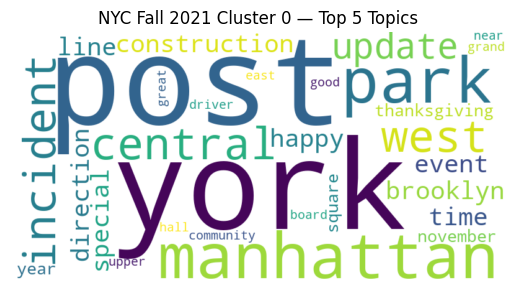

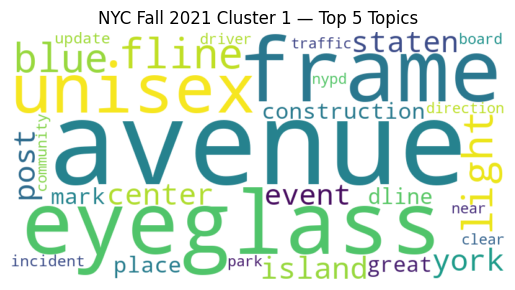

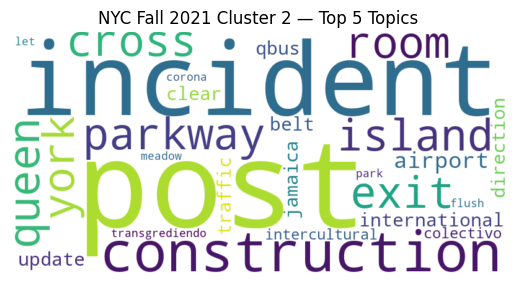

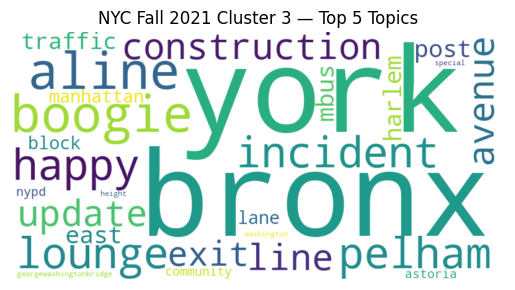

In [30]:
# Wordcloud per cluster
for cluster_id in fall_topics_final['cluster'].unique():
    subset = fall_topics_final[fall_topics_final['cluster'] == cluster_id]
    text = " ".join(subset['keywords'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"NYC Fall 2021 Cluster {cluster_id} — Top 5 Topics")
    plt.show()


In [31]:
# saving all the LDA topics
winter_topics_final.to_csv("Outputs_2021/winter_Cluster_Topics.csv", index=False)
spring_topics_final.to_csv("Outputs_2021/spring_Cluster_Topics.csv", index=False)
summer_topics_final.to_csv("Outputs_2021/summer_Cluster_Topics.csv", index=False)
fall_topics_final.to_csv("Outputs_2021/fall_Cluster_Topics.csv", index=False)

In [33]:
# Combining all seasonal DataFrames into one

seasonal_df = pd.concat([winter_tweets_2021, spring_tweets_2021, summer_tweets_2021, fall_tweets_2021],join="inner",
    ignore_index=True)

# Preview random 5 rows
seasonal_df.sample(5)

,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_clout,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,cluster,cluster_name,tokens
556060,596940,1419371348405727239,2021-07-25 18:57:54+00:00,1627239474,NYC gathers to hear @prezident.sveta #freebela...,en,-74.005891,40.712701,0.000,0.000,...,40.06,12.44,20.23,"Manhattan, NY",US,Summer,month_2021_07.db,0,Downtown Manhattan,"[gather, hear, sveta, freebelarus, york]"
95389,246292,1347576475810226176,2021-01-08 16:10:43+00:00,1610122243,Lane closures removed in #Bronx:OnTheCrossBron...,en,-73.930200,40.845840,0.000,0.066,...,40.06,52.19,2.53,"Manhattan, NY",US,Winter,month_2021_01.db,3,Queens & Eastern Brooklyn,"[lane, closure, remove, bronxonthecrossbronxex..."
814320,648837,1464030348594106369,2021-11-26 00:36:50+00:00,1637887010,All systems operational. https://t.co/csShtOvQ...,en,-74.006400,40.714200,0.103,0.088,...,72.07,3.81,1.00,"Manhattan, NY",US,Fall,month_2021_11.db,0,Downtown Manhattan,"[system, operational, ready, combat, cosplayer..."
366106,40821,1388674146951864323,2021-05-02 01:58:11+00:00,1619920691,Baseball Rules Academy: So Explain This Obstru...,en,-74.000761,40.720756,0.000,0.000,...,40.06,2.93,1.00,"Manhattan, NY",US,Spring,month_2021_05.db,0,Downtown Manhattan,"[baseball, rule, academy, explain, obstruction]"
55474,702072,1341393681463406592,2020-12-22 14:42:30+00:00,1608648150,Just posted a video @ Bedford-Stuyvesant https...,en,-73.940571,40.687674,0.000,0.000,...,40.06,1.00,1.00,"Brooklyn, NY",US,Winter,month_2020_12.db,1,Brooklyn & Staten Island,"[post, bedfordstuyvesant]"


In [34]:
seasonal_df.columns

Index(['item_number', 'tweet_id', 'created_at', 'created_timestamp', 'text',
       'lang', 'geo_lat', 'geo_lon', 'sentiment_pos', 'sentiment_neg',
       'sentiment_compound', 'liwc_analytic', 'liwc_clout', 'liwc_authentic',
       'liwc_tone', 'place_name', 'country_code', 'season', 'source_db',
       'cluster', 'cluster_name', 'tokens'],
      dtype='object')

### Sentiment Analysis

In [35]:

# Categorize based on the existing compound score
seasonal_df['sentiment_label'] = seasonal_df['sentiment_compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)
seasonal_df.sample(5)

,item_number,tweet_id,created_at,created_timestamp,text,lang,geo_lat,geo_lon,sentiment_pos,sentiment_neg,...,liwc_authentic,liwc_tone,place_name,country_code,season,source_db,cluster,cluster_name,tokens,sentiment_label
306260,161444,1379855421591146499,2021-04-07 17:55:43+00:00,1617818143,Accident in #Queens on The Cross Island Pkwy S...,en,-73.740400,40.749910,0.000,0.208,...,24.32,1.00,"Queens, NY",US,Spring,month_2021_04.db,2,Uptown Manhattan & Bronx,"[accident, queen, cross, island, pkwy, alley, ...",Negative
246048,298364,1370350934451232773,2021-03-12 12:28:17+00:00,1615552097,#LiveLaughLove #RaiseHell\n@hellraisermovies #...,en,-73.994247,40.745621,0.000,0.605,...,1.00,1.00,"Manhattan, NY",US,Spring,month_2021_03.db,0,Downtown Manhattan,"[livelaughlove, raisehell, hellraiser, hell]",Negative
445877,134029,1401563126424801283,2021-06-06 15:34:23+00:00,1622993663,@kate.winslet.official Is amazing as Mare in...,en,-73.914236,40.746016,0.328,0.139,...,5.07,96.12,"Queens, NY",US,Summer,month_2021_06.db,0,Downtown Manhattan,"[winsletofficial, amazing, mare, mare, easttow...",Positive
349266,625147,1386295099274022916,2021-04-25 12:24:42+00:00,1619353482,I don't like when we've got a rainy day (@ Bay...,en,-74.015236,40.633822,0.000,0.208,...,70.28,1.00,"Brooklyn, NY",US,Spring,month_2021_04.db,1,Brooklyn & Staten Island,"[like, rainy, ridge, brooklyn]",Negative
328179,406142,1383072757118767105,2021-04-16 15:00:16+00:00,1618585216,My First YouTube Video Is Finally Live! https...,en,-74.000761,40.720756,0.000,0.000,...,89.39,1.00,"Manhattan, NY",US,Spring,month_2021_04.db,0,Downtown Manhattan,"[youtube, finally, live]",Neutral


In [36]:
# Calculate for each season separately
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_sentiments = {}

for season in seasons:
    season_df = seasonal_df[seasonal_df['season'] == season]
    sentiment_summary = season_df.groupby(['cluster', 'sentiment_label']).size().reset_index(name='count')
    sentiment_summary['percentage'] = sentiment_summary.groupby('cluster')['count'].transform(lambda x: 100 * x / x.sum())
    seasonal_sentiments[season] = sentiment_summary

# Access winter results
winter_sentiment = seasonal_sentiments['Winter']
print("Winter Season Sentiment by Cluster:")
spring_sentiment = seasonal_sentiments['Spring']
summer_sentiment = seasonal_sentiments['Summer']
fall_sentiment = seasonal_sentiments['Fall']
winter_sentiment

Winter Season Sentiment by Cluster:


,cluster,sentiment_label,count,percentage
0,0,Negative,8392,6.619602
1,0,Neutral,83313,65.717216
2,0,Positive,35070,27.663183
3,1,Negative,2757,7.068687
4,1,Neutral,24910,63.866882
5,1,Positive,11336,29.064431
6,2,Negative,1248,7.086882
7,2,Neutral,11386,64.656445
8,2,Positive,4976,28.256672
9,3,Negative,3071,8.537670


In [37]:
# saving all the seaonal summaries 
winter_sentiment.to_csv("Outputs_2021/Winter_sentiment_summary.csv", index = False)
spring_sentiment.to_csv("Outputs_2021/Spring_sentiment_summary.csv", index = False)
summer_sentiment.to_csv("Outputs_2021/Summer_sentiment_summary.csv", index = False)
fall_sentiment.to_csv("Outputs_2021/Fall_sentiment_summary.csv", index = False)

In [38]:
# Aggregate Sentiment per Cluster
sentiment_summary = seasonal_df.groupby(['cluster', 'sentiment_label']).size().reset_index(name='count')
sentiment_summary['percentage'] = sentiment_summary.groupby('cluster')['count'].transform(lambda x: 100 * x / x.sum())
sentiment_summary

,cluster,sentiment_label,count,percentage
0,0,Negative,33976,7.527372
1,0,Neutral,294895,65.333898
2,0,Positive,122495,27.138730
3,1,Negative,12850,7.577053
4,1,Neutral,114839,67.715268
5,1,Positive,41902,24.707679
6,2,Negative,6085,8.185585
7,2,Neutral,48282,64.949286
8,2,Positive,19971,26.865130
9,3,Negative,13063,10.339805


<Figure size 1200x600 with 0 Axes>

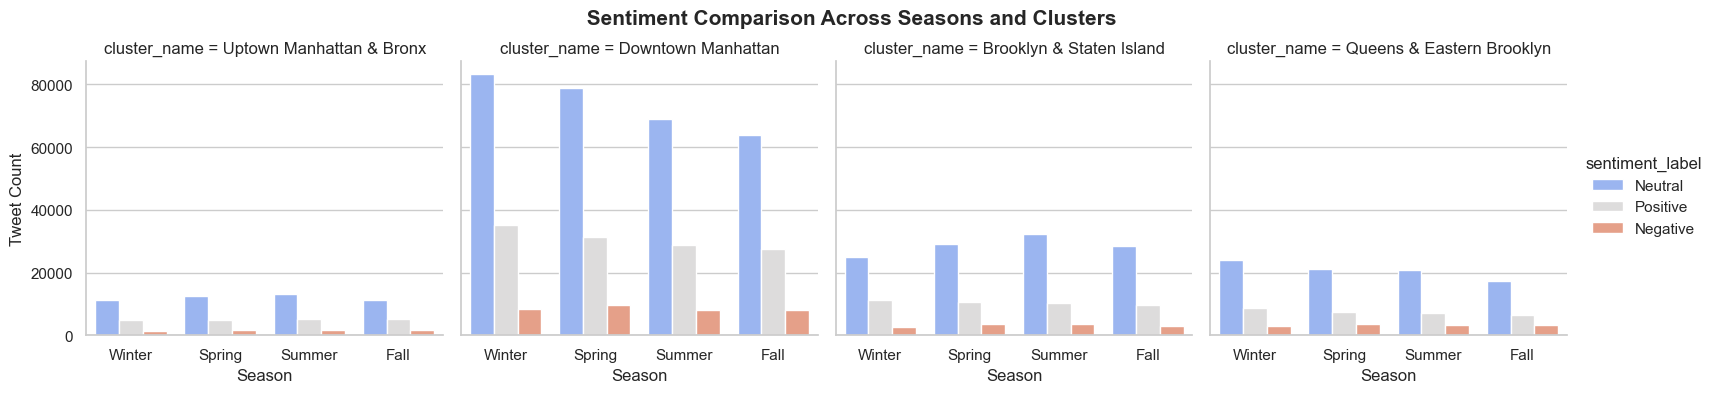

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=seasonal_df,
    x="season",
    hue="sentiment_label",
    col="cluster_name",
    kind="count",
    order=["Winter", "Spring", "Summer", "Fall"],
    palette="coolwarm",
    height=4, aspect=1
)

g.fig.suptitle(" Sentiment Comparison Across Seasons and Clusters", fontsize=15, weight='bold')
g.set_axis_labels("Season", "Tweet Count")
#g.add_legend(title="Sentiment")
plt.subplots_adjust(top=0.85)
plt.show()


In [40]:
import pandas as pd
import plotly.express as px

try:
    # Load seasonal sentiment summaries
    dfs = []
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        temp = pd.read_csv(f"Outputs_2021/{season.lower()}_sentiment_summary.csv")
        temp['season'] = season
        dfs.append(temp)

    # Combine all
    seasonal_sentiment = pd.concat(dfs, ignore_index=True)

    # Ensure proper seasonal order
    season_order = ["Winter", "Spring", "Summer", "Fall"]
    seasonal_sentiment["season"] = pd.Categorical(seasonal_sentiment["season"], categories=season_order, ordered=True)

    # Calculate percentage distribution per season
    seasonal_sentiment['percentage'] = seasonal_sentiment.groupby('season')['count'].transform(
        lambda x: 100 * x / x.sum()
    )

    # Create area chart
    fig = px.area(
        seasonal_sentiment,
        x="season",
        y="percentage",   # use normalized percentage
        color="sentiment_label",
        line_group="sentiment_label",
        title="🌀 Sentiment Distribution Over Seasons in NYC",
        template="plotly_white",
        labels={
            "percentage": "Percentage (%)",
            "season": "Season",
            "sentiment_label": "Sentiment"
        },
        color_discrete_map={
            "Positive": "#2ECC71",
            "Neutral": "#95A5A6", 
            "Negative": "#E74C3C"
        }
    )

    # Style and layout improvements
    fig.update_layout(
        xaxis_title="Season",
        yaxis_title="Tweet Share (%)",
        legend_title="Sentiment",
        title_x=0.5,
        font=dict(size=13),
        plot_bgcolor='rgba(0,0,0,0)',
        hovermode="x unified"
    )

    fig.update_traces(mode='lines', line=dict(width=2))
    
    # Try different rendering methods
    try:
        fig.show()
    except:
        print("Interactive display not available. Saving as HTML file...")
        fig.write_html("seasonal_sentiment_plot.html")
        print("Plot saved as 'seasonal_sentiment_plot.html'. Open this file in your browser.")
        
except Exception as e:
    print(f"Error: {e}")
    print("Please install nbformat: pip install nbformat>=4.2.0")

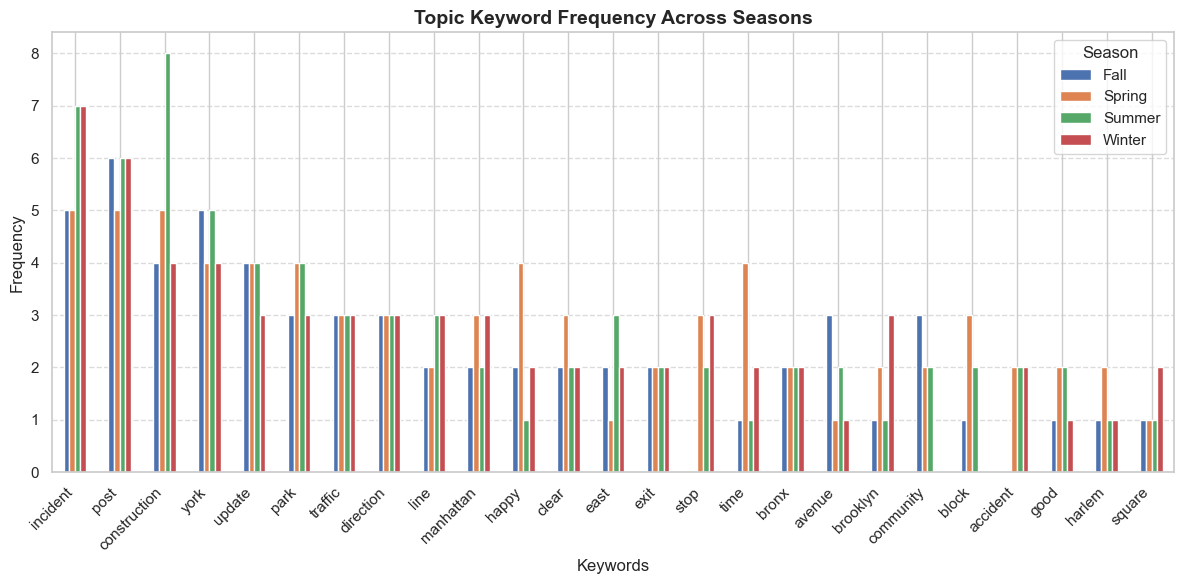

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file mapping for each season
topic_files = {
    'Winter': 'Outputs_2021/winter_Cluster_Topics.csv',
    'Spring': 'Outputs_2021/spring_Cluster_Topics.csv',
    'Summer': 'Outputs_2021/summer_Cluster_Topics.csv',
    'Fall': 'Outputs_2021/fall_Cluster_Topics.csv'
}


# Combine all topics into one DataFrame
all_topics = []
for season, file in topic_files.items():
    if os.path.exists(file):
        df = pd.read_csv(file)
        df['season'] = season
        
        # Split comma-separated keywords
        df['keywords'] = df['keywords'].str.split(',')
        df = df.explode('keywords')
        df['keywords'] = df['keywords'].str.strip()
        
        all_topics.append(df[['season', 'keywords']])
    else:
        print(f"⚠️ File not found: {file}")

topics_df = pd.concat(all_topics, ignore_index=True)

# Count keyword frequency per season
topic_freq = topics_df.groupby(['season', 'keywords']).size().reset_index(name='count')

# Pivot for visualization
topic_pivot = topic_freq.pivot(index='keywords', columns='season', values='count').fillna(0)

# Filter top 25 most frequent keywords overall
top_keywords = topic_pivot.sum(axis=1).sort_values(ascending=False).head(25).index
topic_pivot_top = topic_pivot.loc[top_keywords]

# --- Visualization 1: Bar chart ---
topic_pivot_top.plot(kind='bar', figsize=(12, 6))
plt.title("Topic Keyword Frequency Across Seasons", fontsize=14, weight='bold')
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Topic to sentiment mapping

##### Winter_2021

In [46]:
# ✅ Rename for simplicity
winter_tweets_df = winter_tweets_2021.copy()
winter_topics_df = winter_topics_final.copy()

# --- Clean & standardize columns ---
winter_tweets_df.columns = winter_tweets_df.columns.str.strip().str.lower()
winter_topics_df.columns = winter_topics_df.columns.str.strip().str.lower()

In [50]:

# Ensure required columns exist
assert {'text', 'sentiment_compound', 'cluster'}.issubset(winter_tweets_df.columns), "Missing columns in tweets dataset"
assert {'cluster', 'topic_id', 'keywords'}.issubset(winter_topics_df.columns), "Missing columns in topics dataset"


In [51]:
# Clean and Split Topic Keywords
winter_topics_df['keywords'] = winter_topics_df['keywords'].astype(str).str.split(',')
winter_topics_df = winter_topics_df.explode('keywords')
winter_topics_df['keywords'] = winter_topics_df['keywords'].str.strip().str.lower()

In [52]:
#  Map Topics to Tweets 
def match_topics(text, cluster, topic_data):
    """Return list of topic IDs whose keywords appear in the tweet text (for that cluster)."""
    text = str(text).lower()
    cluster_topics = topic_data[topic_data['cluster'] == cluster]
    matched_topics = []
    for _, row in cluster_topics.iterrows():
        kw = row['keywords']
        if re.search(rf'\b{re.escape(kw)}\b', text):
            matched_topics.append(row['topic_id'])
    return list(set(matched_topics))

winter_tweets_df['matched_topics'] = winter_tweets_df.progress_apply(
    lambda x: match_topics(x['text'], x['cluster'], topics_df), axis=1
)


Cleaning tweets: 100%|██████████| 219358/219358 [04:12<00:00, 868.35it/s] 


In [53]:
#  Explode to One Row per Topic 
tweets_exploded = winter_tweets_df.explode('matched_topics').dropna(subset=['matched_topics'])

In [54]:

#  Aggregate Sentiment by Topic and Cluster
winter_topic_sentiment = (
    tweets_exploded.groupby(['cluster', 'matched_topics'])
    ['sentiment_compound']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'matched_topics': 'topic_id',
        'mean': 'avg_sentiment',
        'count': 'tweet_count'
    })
)

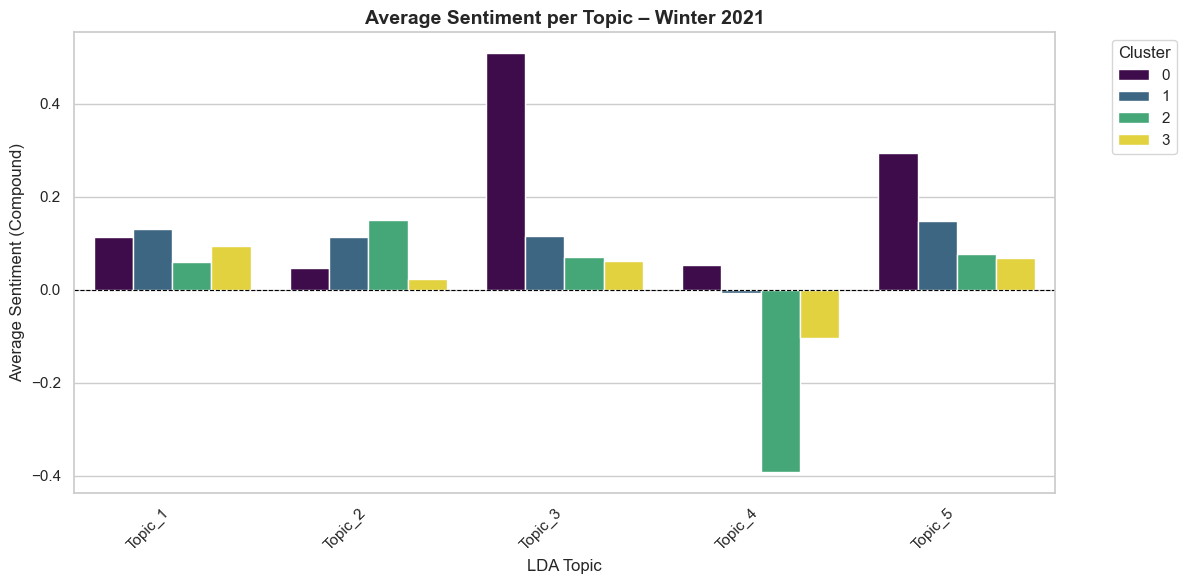

In [ ]:
#  Visualize Average Sentiment per Topic
plt.figure(figsize=(12, 6))
sns.barplot(data=winter_topic_sentiment, x='topic_id', y='avg_sentiment', hue='cluster', palette='viridis')
plt.title("Average Sentiment per Topic – Winter 2021", fontsize=14, weight='bold')
plt.xlabel("LDA Topic")
plt.ylabel("Average Sentiment (Compound)")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Spring_2021

In [57]:
# ✅ Rename for simplicity
spring_tweets_df = spring_tweets_2021.copy()
spring_topics_df = winter_topics_final.copy()

# --- Clean & standardize columns ---
spring_tweets_df.columns = spring_tweets_df.columns.str.strip().str.lower()
spring_topics_df.columns = spring_topics_df.columns.str.strip().str.lower()

In [58]:

# Ensure required columns exist
assert {'text', 'sentiment_compound', 'cluster'}.issubset(spring_tweets_df.columns), "Missing columns in tweets dataset"
assert {'cluster', 'topic_id', 'keywords'}.issubset(spring_topics_df.columns), "Missing columns in topics dataset"


In [59]:
# Clean and Split Topic Keywords
spring_topics_df['keywords'] = spring_topics_df['keywords'].astype(str).str.split(',')
spring_topics_df = spring_topics_df.explode('keywords')
spring_topics_df['keywords'] = spring_topics_df['keywords'].str.strip().str.lower()

In [60]:
#  Map Topics to Tweets 
spring_tweets_df['matched_topics'] = spring_tweets_df.progress_apply(
    lambda x: match_topics(x['text'], x['cluster'], topics_df), axis=1
)


Cleaning tweets: 100%|██████████| 213751/213751 [03:58<00:00, 896.90it/s] 


In [61]:
#  Explode to One Row per Topic 
tweets_exploded = spring_tweets_df.explode('matched_topics').dropna(subset=['matched_topics'])

In [62]:

#  Aggregate Sentiment by Topic and Cluster
spring_topic_sentiment = (
    tweets_exploded.groupby(['cluster', 'matched_topics'])
    ['sentiment_compound']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'matched_topics': 'topic_id',
        'mean': 'avg_sentiment',
        'count': 'tweet_count'
    })
)

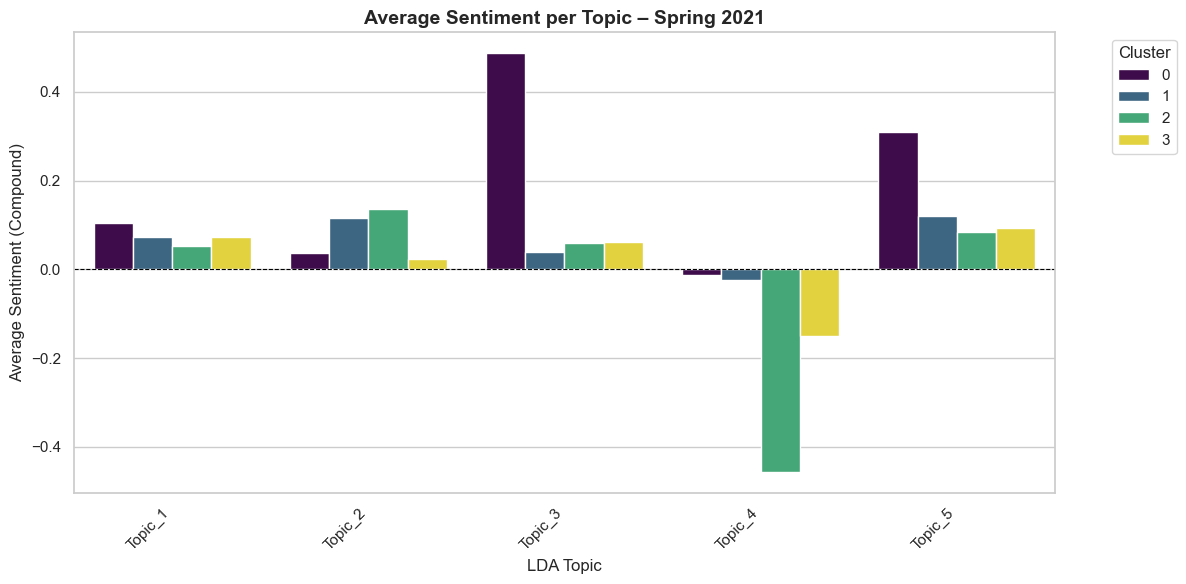

In [79]:
#  Visualize Average Sentiment per Topic
plt.figure(figsize=(12, 6))
sns.barplot(data=spring_topic_sentiment, x='topic_id', y='avg_sentiment', hue='cluster', palette='viridis')
plt.title("Average Sentiment per Topic – Spring 2021", fontsize=14, weight='bold')
plt.xlabel("LDA Topic")
plt.ylabel("Average Sentiment (Compound)")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Summer_2021

In [64]:
# ✅ Rename for simplicity
summer_tweets_df = summer_tweets_2021.copy()
summer_topics_df = summer_topics_final.copy()

# --- Clean & standardize columns ---
summer_tweets_df.columns = summer_tweets_df.columns.str.strip().str.lower()
summer_topics_df.columns = summer_topics_df.columns.str.strip().str.lower()

In [65]:

# Ensure required columns exist
assert {'text', 'sentiment_compound', 'cluster'}.issubset(summer_tweets_df.columns), "Missing columns in tweets dataset"
assert {'cluster', 'topic_id', 'keywords'}.issubset(summer_topics_df.columns), "Missing columns in topics dataset"


In [66]:
# Clean and Split Topic Keywords
summer_topics_df['keywords'] = summer_topics_df['keywords'].astype(str).str.split(',')
summer_topics_df = summer_topics_df.explode('keywords')
summer_topics_df['keywords'] = summer_topics_df['keywords'].str.strip().str.lower()

In [67]:
#  Map Topics to Tweets 
summer_tweets_df['matched_topics'] = summer_tweets_df.progress_apply(
    lambda x: match_topics(x['text'], x['cluster'], topics_df), axis=1
)


Cleaning tweets: 100%|██████████| 202923/202923 [04:43<00:00, 716.83it/s]


In [68]:
#  Explode to One Row per Topic 
tweets_exploded = summer_tweets_df.explode('matched_topics').dropna(subset=['matched_topics'])

In [69]:

#  Aggregate Sentiment by Topic and Cluster
summer_topic_sentiment = (
    tweets_exploded.groupby(['cluster', 'matched_topics'])
    ['sentiment_compound']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'matched_topics': 'topic_id',
        'mean': 'avg_sentiment',
        'count': 'tweet_count'
    })
)

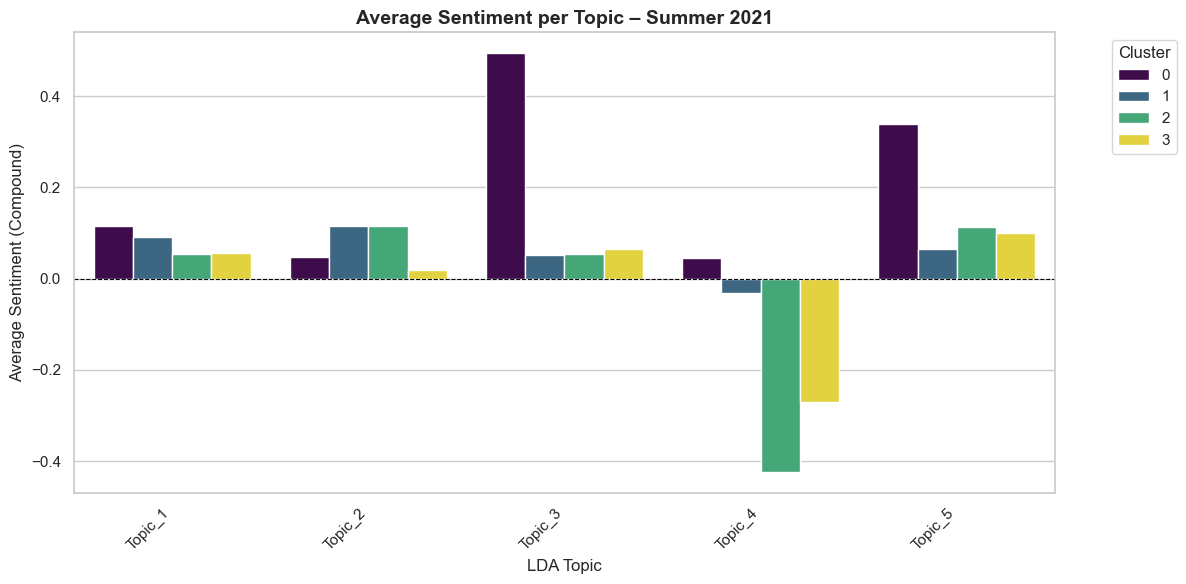

In [78]:
#  Visualize Average Sentiment per Topic
plt.figure(figsize=(12, 6))
sns.barplot(data=summer_topic_sentiment, x='topic_id', y='avg_sentiment', hue='cluster', palette='viridis')
plt.title("Average Sentiment per Topic – Summer 2021", fontsize=14, weight='bold')
plt.xlabel("LDA Topic")
plt.ylabel("Average Sentiment (Compound)")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Fall_2021

In [71]:
# ✅ Rename for simplicity
fall_tweets_df = fall_tweets_2021.copy()
fall_topics_df = fall_topics_final.copy()

# --- Clean & standardize columns ---
fall_tweets_df.columns = fall_tweets_df.columns.str.strip().str.lower()
fall_topics_df.columns = fall_topics_df.columns.str.strip().str.lower()

In [72]:

# Ensure required columns exist
assert {'text', 'sentiment_compound', 'cluster'}.issubset(fall_tweets_df.columns), "Missing columns in tweets dataset"
assert {'cluster', 'topic_id', 'keywords'}.issubset(fall_topics_df.columns), "Missing columns in topics dataset"


In [73]:
# Clean and Split Topic Keywords
fall_topics_df['keywords'] = fall_topics_df['keywords'].astype(str).str.split(',')
fall_topics_df = fall_topics_df.explode('keywords')
fall_topics_df['keywords'] = fall_topics_df['keywords'].str.strip().str.lower()

In [74]:
#  Map Topics to Tweets 
fall_tweets_df['matched_topics'] = fall_tweets_df.progress_apply(
    lambda x: match_topics(x['text'], x['cluster'], topics_df), axis=1
)


Cleaning tweets: 100%|██████████| 185600/185600 [04:11<00:00, 737.18it/s]


In [75]:
#  Explode to One Row per Topic 
tweets_exploded = fall_tweets_df.explode('matched_topics').dropna(subset=['matched_topics'])

In [76]:

#  Aggregate Sentiment by Topic and Cluster
fall_topic_sentiment = (
    tweets_exploded.groupby(['cluster', 'matched_topics'])
    ['sentiment_compound']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={
        'matched_topics': 'topic_id',
        'mean': 'avg_sentiment',
        'count': 'tweet_count'
    })
)

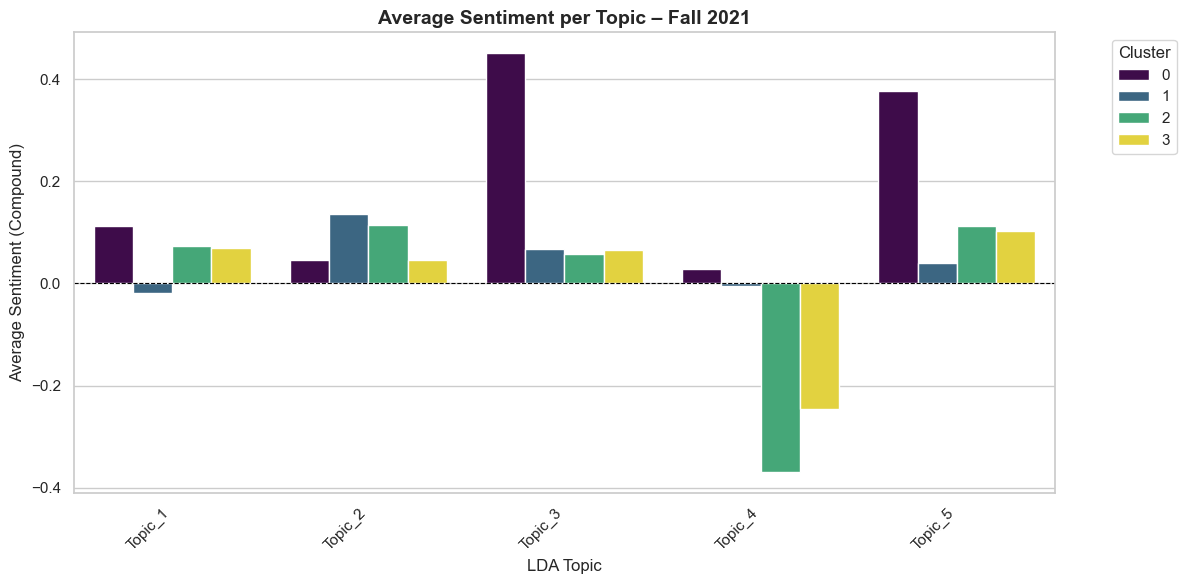

In [77]:
#  Visualize Average Sentiment per Topic
plt.figure(figsize=(12, 6))
sns.barplot(data=fall_topic_sentiment, x='topic_id', y='avg_sentiment', hue='cluster', palette='viridis')
plt.title("Average Sentiment per Topic – Fall 2021", fontsize=14, weight='bold')
plt.xlabel("LDA Topic")
plt.ylabel("Average Sentiment (Compound)")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [83]:
# Saving all the topic sentiments to csv
winter_topic_sentiment.to_csv("Outputs_2021/winter_topic_senitments.csv", index = False)
spring_topic_sentiment.to_csv("Outputs_2021/spring_topic_senitments.csv", index = False)
summer_topic_sentiment.to_csv("Outputs_2021/summer_topic_senitments.csv", index = False)
fall_topic_sentiment.to_csv("Outputs_2021/fall_topic_senitments.csv", index = False)


In [84]:
# --- Load all four seasonal topic–sentiment summary files ---
files = {
    'Winter': 'Outputs_2021/winter_topic_senitments.csv',
    'Spring': 'Outputs_2021/spring_topic_senitments.csv',
    'Summer': 'Outputs_2021/summer_topic_senitments.csv',
    'Fall': 'Outputs_2021/fall_topic_senitments.csv'
}

dfs = []
for season, path in files.items():
    df = pd.read_csv(path)
    df['season'] = season
    dfs.append(df)

# Combine all seasons
topic_drift_df = pd.concat(dfs, ignore_index=True)


In [85]:

# Clean topic naming (remove extra spaces, etc.) 
topic_drift_df['topic_id'] = topic_drift_df['topic_id'].str.strip()

# Average across clusters (optional for overall trend) 
topic_trend = (
    topic_drift_df.groupby(['season', 'topic_id'])
    .agg({'avg_sentiment': 'mean', 'tweet_count': 'sum'})
    .reset_index()
)

In [86]:
# Order seasons chronologically 
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
topic_trend['season'] = pd.Categorical(topic_trend['season'], categories=season_order, ordered=True)


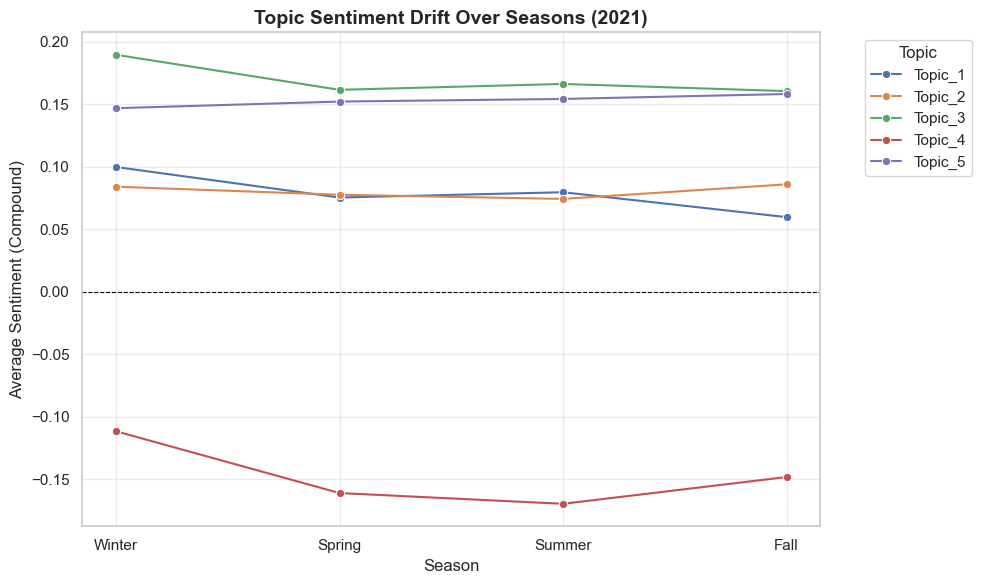

In [87]:
#  Sentiment Drift Line Plot 
plt.figure(figsize=(10,6))
sns.lineplot(data=topic_trend, x='season', y='avg_sentiment', hue='topic_id', marker='o')
plt.title("Topic Sentiment Drift Over Seasons (2021)", fontsize=14, weight='bold')
plt.xlabel("Season")
plt.ylabel("Average Sentiment (Compound)")
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

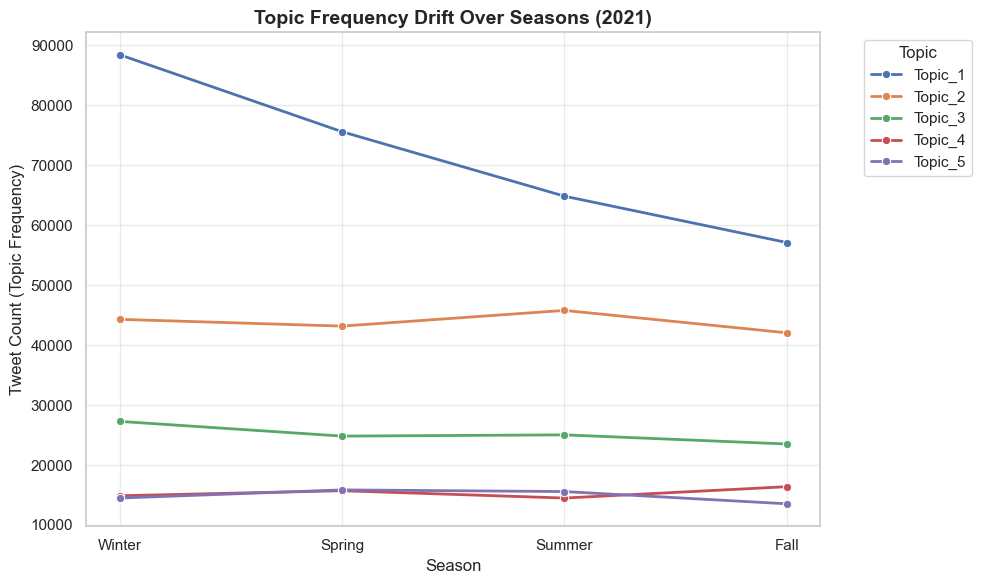

In [88]:
# Frequency Drift Stream
plt.figure(figsize=(10,6))
sns.lineplot(data=topic_trend, x='season', y='tweet_count', hue='topic_id', marker='o', linewidth=2)
plt.title("Topic Frequency Drift Over Seasons (2021)", fontsize=14, weight='bold')
plt.xlabel("Season")
plt.ylabel("Tweet Count (Topic Frequency)")
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Heat Map for tweets density per season
from folium.plugins import HeatMap
import folium
from IPython.display import display, HTML

for label in tweets_2021['season'].unique():
    subset = tweets_2021[tweets_2021['season'] == label]
    
    # Center map around seasonal average coordinates
    m = folium.Map(location=[subset['geo_lon'].mean(), subset['geo_lat'].mean()], zoom_start=11)
    
    # Add heatmap layer
    HeatMap(subset[['geo_lon', 'geo_lat']].values, radius=10).add_to(m)
    
    # --- Add Title Overlay ---
    title_html = f'''
        <h3 align="center" style="font-size:20px">
            <b>Tweet Density Heatmap — {label} 2021</b>
        </h3>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    m.save(f"Outputs_2021/tweet_density_heatmap_{label.lower()}.html")